In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("C:\Dataset\Global-Superstore.csv")

def parse_date(x):
    for fmt in ("%m-%d-%y", "%m/%d/%Y", "%Y-%m-%d"):
        try:
            return pd.to_datetime(x, format=fmt)
        except:
            continue
    return pd.NaT  # if none match

df['Order Date'] = df['Order Date'].apply(parse_date)
df['Order Date'] = df['Order Date'].dt.strftime('%Y-%m-%d')
df['Order Date'].reset_index()
df['Order Date']

def parse_date(x):
    for fmt in ("%m-%d-%y", "%m/%d/%Y", "%Y-%m-%d"):
        try:
            return pd.to_datetime(x, format=fmt)
        except:
            continue
    return pd.NaT  # if none match

df['Ship Date'] = df['Ship Date'].apply(parse_date)
df['Ship Date'] = df['Ship Date'].dt.strftime('%Y-%m-%d')
df['Ship Date'].reset_index()
df['Ship Date']

df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,29002,IN-2014-62366,2014-06-19,2014-06-19,Same Day,KE-16420,Katrina Edelman,Corporate,Kure,Hiroshima,...,OFF-FA-10000746,Office Supplies,Fasteners,"Advantus Thumb Tacks, 12 Pack",65.100,5,0.0,4.5000,0.01,Medium
51286,35398,US-2014-102288,2014-06-20,2014-06-24,Standard Class,ZC-21910,Zuschuss Carroll,Consumer,Houston,Texas,...,OFF-AP-10002906,Office Supplies,Appliances,Hoover Replacement Belt for Commercial Guardsm...,0.444,1,0.8,-1.1100,0.01,Medium
51287,40470,US-2013-155768,2013-12-02,2013-12-02,Same Day,LB-16795,Laurel Beltran,Home Office,Oxnard,California,...,OFF-EN-10001219,Office Supplies,Envelopes,"#10- 4 1/8"" x 9 1/2"" Security-Tint Envelopes",22.920,3,0.0,11.2308,0.01,High
51288,9596,MX-2012-140767,2012-02-18,2012-02-22,Standard Class,RB-19795,Ross Baird,Home Office,Valinhos,S‹o Paulo,...,OFF-BI-10000806,Office Supplies,Binders,"Acco Index Tab, Economy",13.440,2,0.0,2.4000,0.00,Medium


In [ ]:
df.info

<bound method DataFrame.info of        Row ID         Order ID  Order Date   Ship Date       Ship Mode  \
0       32298   CA-2012-124891   7/31/2012   7/31/2012        Same Day   
1       26341    IN-2013-77878    02-05-13    02-07-13    Second Class   
2       25330    IN-2013-71249  10/17/2013  10/18/2013     First Class   
3       13524  ES-2013-1579342   1/28/2013   1/30/2013     First Class   
4       47221     SG-2013-4320    11-05-13    11-06-13        Same Day   
...       ...              ...         ...         ...             ...   
51285   29002    IN-2014-62366   6/19/2014   6/19/2014        Same Day   
51286   35398   US-2014-102288   6/20/2014   6/24/2014  Standard Class   
51287   40470   US-2013-155768    12-02-13    12-02-13        Same Day   
51288    9596   MX-2012-140767   2/18/2012   2/22/2012  Standard Class   
51289    6147   MX-2012-134460   5/22/2012   5/26/2012    Second Class   

      Customer ID     Customer Name      Segment           City  \
0        RH-

Sales performance by Region


Question: Which region generates the highest sales?

In [6]:
region_sales = df[['Region', 'Country', 'Sales']]

sales_by_region = (
    region_sales
    .groupby(['Region', 'Country'])['Sales']
    .sum()
    .reset_index()
    .round(2)
)

top_regions = sales_by_region.sort_values(by='Sales', ascending=False).head(10)

top_regions.reset_index(drop=True)

,Region,Country,Sales
0,Oceania,Australia,925235.85
1,Central,France,858931.08
2,West,United States,725457.82
3,North Asia,China,700562.02
4,East,United States,678781.24
5,Central,Germany,628840.03
6,North,Mexico,622590.62
7,Central Asia,India,589650.10
8,North,United Kingdom,528576.30
9,Central,United States,501239.89


Visuals

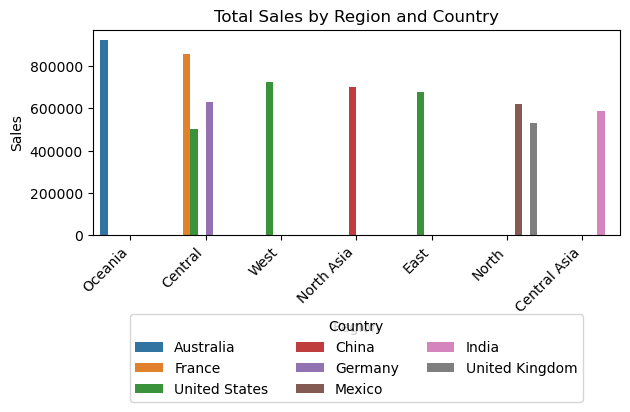

In [13]:
sns.barplot(data=top_regions, x='Region', y='Sales', hue='Country', dodge=True)

plt.title('Total Sales by Region and Country')
plt.xlabel('Region')
plt.ylabel('Sales')

# place legend below the plot
plt.legend(title='Country', loc='upper center', bbox_to_anchor=(0.5, -0.35),
           ncol=3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Profitability by Product Category

Question: Which product category generate the most profit

In [16]:
category_profit = df[['Category', 'Profit']]
profit_by_category = (category_profit
.groupby('Category')['Profit']
.sum().round(2)
.reset_index()
.sort_values(by='Profit', ascending=False)
)
profit_by_category

,Category,Profit
2,Technology,663778.73
1,Office Supplies,518473.83
0,Furniture,285204.72


Visuals

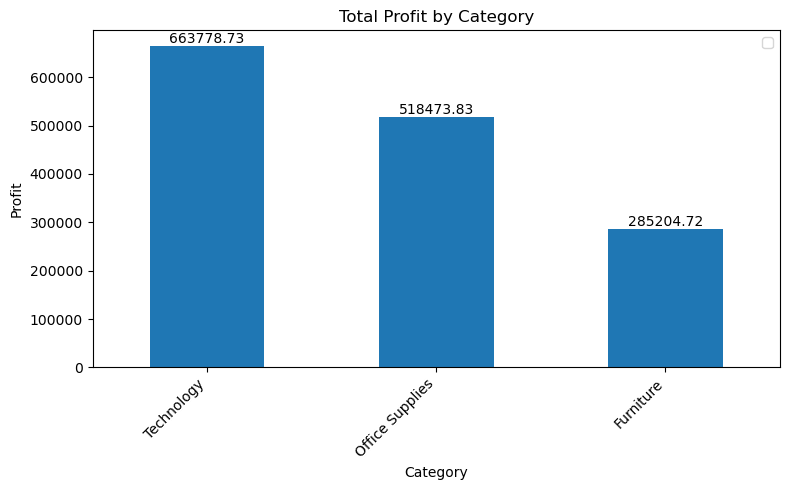

In [15]:
ax = profit_by_category.plot(kind='bar', x='Category', y='Profit', figsize=(8,5))
plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.xticks(rotation=45, ha='right')

# annotate each bar with its value
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}',
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom')

plt.tight_layout()
plt.legend('')
plt.show()

Sales Trend Over Time

Question: How has sales changed over time

In [25]:
sales_date = df[['Order Date', 'Sales']]

sales_date['Order Date'] = pd.to_datetime(sales_date['Order Date'])

monthly_sales = (
    sales_date
    .groupby(sales_date['Order Date'].dt.to_period('M'))['Sales']
    .sum()
    .reset_index(name='Total Monthly Sales')
    .round(2)
    .sort_values('Total Monthly Sales', ascending=False)
    .reset_index(drop=True)
)

monthly_sales

C:\Users\Linda\AppData\Local\Temp\ipykernel_8060\2462840245.py:10: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(2)


,Order Date,Total Monthly Sales
0,2014-11,555279.03
1,2014-12,503143.69
2,2014-09,481157.24
3,2014-08,456619.94
4,2014-10,422766.63
5,2013-12,405454.38
6,2014-06,401814.06
7,2013-06,396519.61
8,2013-09,376619.25
9,2013-11,373989.36


Visual

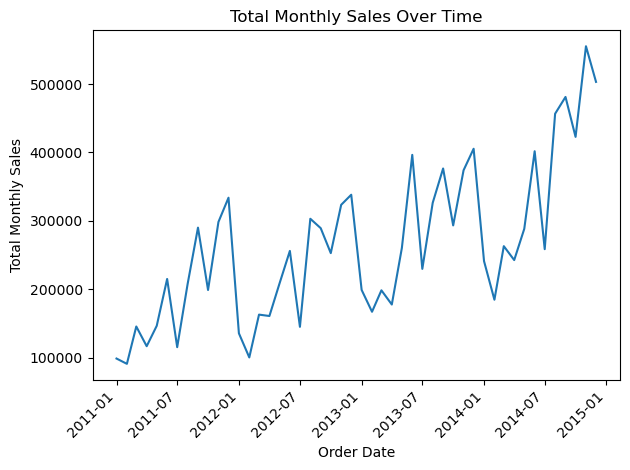

In [30]:
# convert Order Date period to datetime for plotting
monthly_sales['Order Date'] = monthly_sales['Order Date'].dt.to_timestamp()

# use seaborn for a clean line chart
sns.lineplot(data=monthly_sales, x='Order Date', y='Total Monthly Sales')
plt.title('Total Monthly Sales Over Time')
plt.xlabel('Order Date')
plt.ylabel('Total Monthly Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Top 10 Customers by Revenue

Question: Which customer generates the highest revenue.

In [7]:
customer_sales = df[['Customer Name', 'Sales', 'Profit']]
top_customers = (
    customer_sales.groupby(customer_sales['Customer Name'])['Sales']
    .sum().sort_values(ascending=False)
    .round(2).head(10)
    .reset_index()
)
top_customers

,Customer Name,Sales
0,Tom Ashbrook,40488.07
1,Tamara Chand,37457.33
2,Greg Tran,35550.95
3,Christopher Conant,35187.08
4,Sean Miller,35170.93
5,Bart Watters,32310.45
6,Natalie Fritzler,31781.26
7,Fred Hopkins,30400.67
8,Jane Waco,30288.45
9,Hunter Lopez,30243.57


Visuals

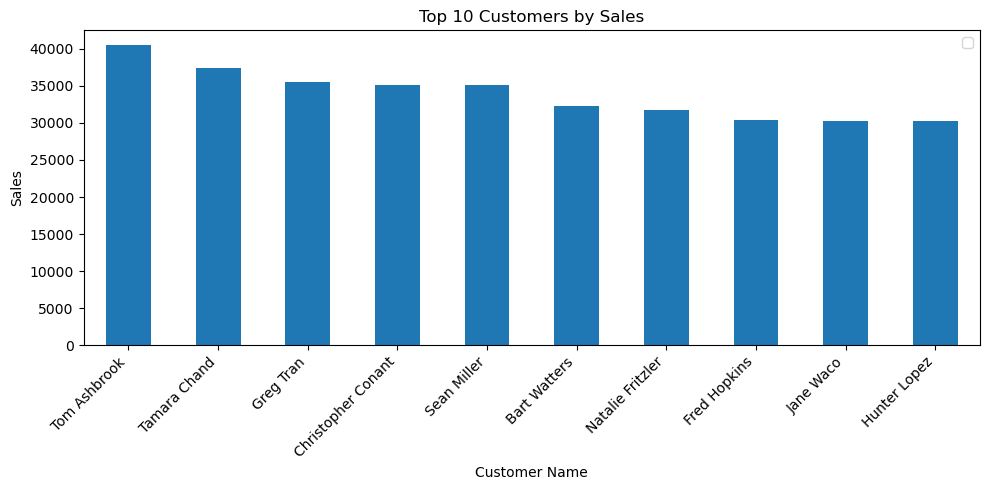

In [23]:
top_customers.plot(kind='bar', x='Customer Name', y='Sales', figsize=(10,5))
plt.title('Top 10 Customers by Sales')
plt.xlabel("Customer Name")
plt.ylabel('Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend('')
plt.show()

Relationship Between Sales and Profit

Question: What is the relationship between sales and profit

In [17]:
sales_profit = df[['Sales', 'Profit']]
sales_profit.head().round(2)

,Sales,Profit
0,2309.65,762.18
1,3709.40,-288.76
2,5175.17,919.97
3,2892.51,-96.54
4,2832.96,311.52


Visualization

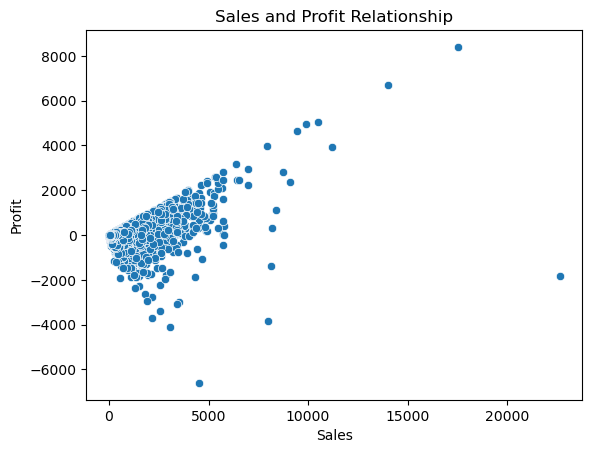

In [18]:
sns.scatterplot(data=sales_profit, x= 'Sales', y='Profit')
plt.title('Sales and Profit Relationship')
plt.show()